# Linear least-squares fitting

Interpolation finds a curve that passes through **every** data point. Real measurements carry
noise, so forcing a curve through every point fits the noise as well as the signal. Instead we
choose a simple model and find the version of it that passes as **close as possible** to all
the points at once.

This notebook fits a straight line by linear least squares, works through the platinum
thermometer example from the lectures, and then looks at Anscombe's quartet: four data sets
that give exactly the same fitted line but could hardly be more different.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# The below commands make the font and image size bigger
plt.rcParams.update({'font.size': 22})
plt.rcParams["figure.figsize"] = (15,10)

## The least-squares line

We have data $(x_i, y_i)$ for $i = 1, \ldots, n$ and a model $f(x) = mx + c$. At each data point
the model and the measurement disagree by the **residual**

$$ r_i = m x_i + c - y_i . $$

Least squares chooses $m$ and $c$ to minimise the sum of the squared residuals,

$$ S(m, c) = \sum_{i=1}^n (m x_i + c - y_i)^2 . $$

Setting $\partial S/\partial m = 0$ and $\partial S/\partial c = 0$ gives the **normal equations**

$$
\begin{pmatrix} \sum x_i^2 & \sum x_i \\ \sum x_i & n \end{pmatrix}
\begin{pmatrix} m \\ c \end{pmatrix}
= \begin{pmatrix} \sum x_i y_i \\ \sum y_i \end{pmatrix} .
$$

The second equation divided by $n$ says $m\bar x + c = \bar y$, where $\bar x$ and $\bar y$ are the
means of the data: the best-fit line always passes through the centroid $(\bar x, \bar y)$. If we
measure $x$ from its mean the two equations decouple, and we get

$$ m = \frac{\sum_i (x_i - \bar x)\,y_i}{\sum_i (x_i - \bar x)^2}, \qquad c = \bar y - m\bar x . $$

This centred form gives the same line as the normal equations but keeps the numbers small, which
avoids the cancellation problems we met in Week 1. Below is a function that implements it.

In [3]:
# For the arguments:
#     x and y are NumPy arrays holding the data points (x_i, y_i).
# It returns the slope m and the intercept c of the least-squares line y = m x + c.
def LeastSquaresLine(x, y):
    """Return (m, c) minimising the squared residuals of y = m x + c."""
    xbar, ybar = np.mean(x), np.mean(y)
    X = x - xbar                         # centred data: sum(X) = 0
    m = np.sum(X*y) / np.sum(X*X)
    c = ybar - m*xbar
    return m, c

## Example: a platinum resistance thermometer

This is the example from the lectures. The resistance $R$ of a platinum thermometer was measured
at five temperatures $T$, and we want to fit $R(T) = mT + c$ and use it to estimate the resistance
at $50^\circ$C.

In [4]:
T = np.array([20.5, 32.7, 51.0, 73.2, 95.7])     # temperature in degrees C
R = np.array([765., 826., 873., 942., 1032.])     # resistance in ohms

m, c = LeastSquaresLine(T, R)
print("m =", m, "ohms per degree C")
print("c =", c, "ohms")

m = 3.3948725229965824 ohms per degree C
c = 702.1720627939267 ohms


These agree with the values we found by hand in the lectures, $m = 3.395\ \Omega/^\circ$C and
$c = 702.2\ \Omega$. Now we can use the fit to estimate the resistance at $50^\circ$C:

In [5]:
print("R(50) =", m*50 + c, "ohms")

R(50) = 871.9156889437558 ohms


As a check, the line should pass through the centroid of the data:

In [6]:
print("mean of R:              ", np.mean(R))
print("line evaluated at mean T:", m*np.mean(T) + c)

mean of R:               887.6
line evaluated at mean T: 887.6


Let's plot the data and the fitted line.

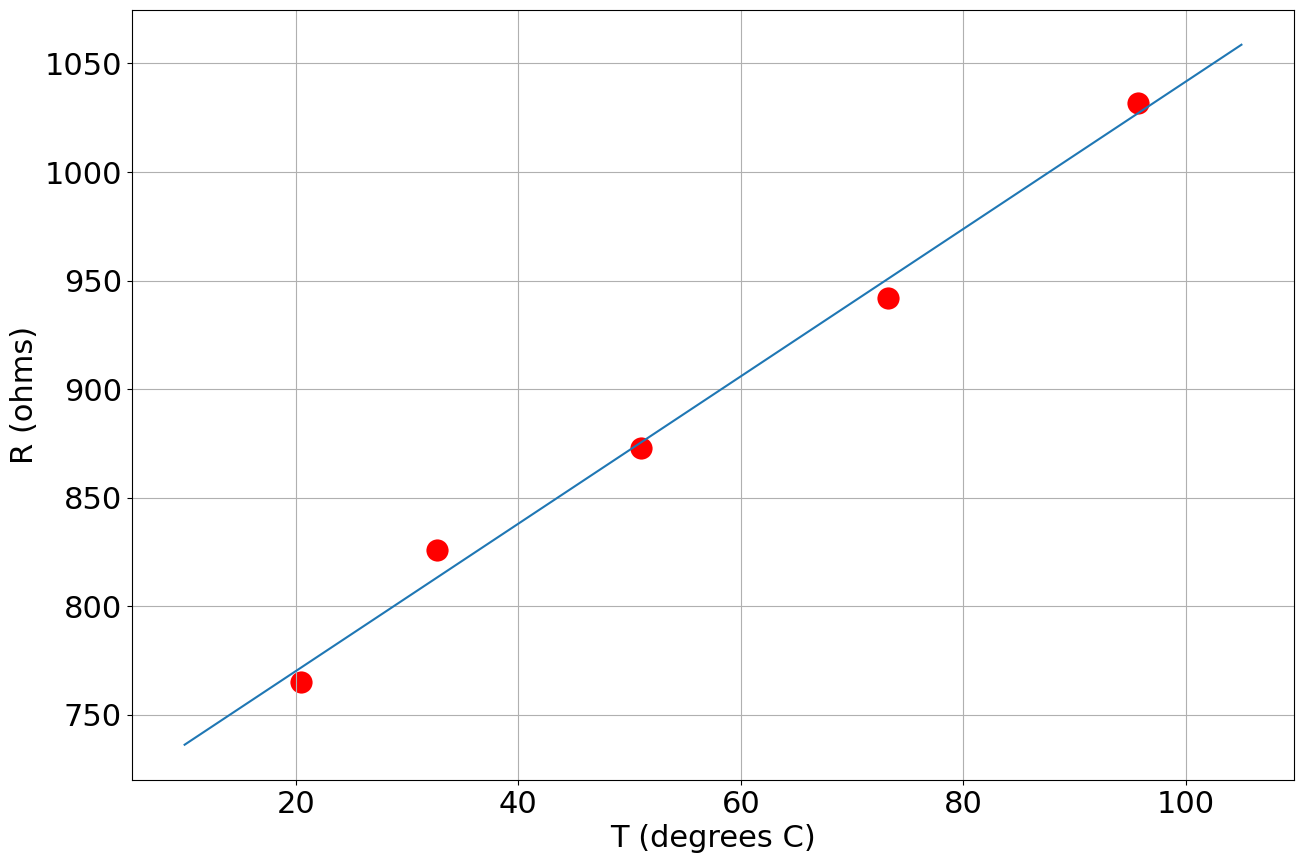

In [7]:
Tplot = np.linspace(10, 105, 100)

plt.grid(True)
plt.xlabel('T (degrees C)')
plt.ylabel('R (ohms)')
plt.scatter(T, R, color='red', linewidths=10);
plt.plot(Tplot, m*Tplot + c);

### The residuals

The fit always returns *a* line, whether or not a line is a good model. The way to check is to
plot the residuals $r_i$ against $x_i$. If the model is right they should be small, scattered
either side of zero with no pattern. The normal equations also guarantee that they sum to zero.

residuals: [  6.76694952 -12.8156057    2.31056147   8.67673148  -4.93863676]
sum of residuals: -1.1368683772161603e-13


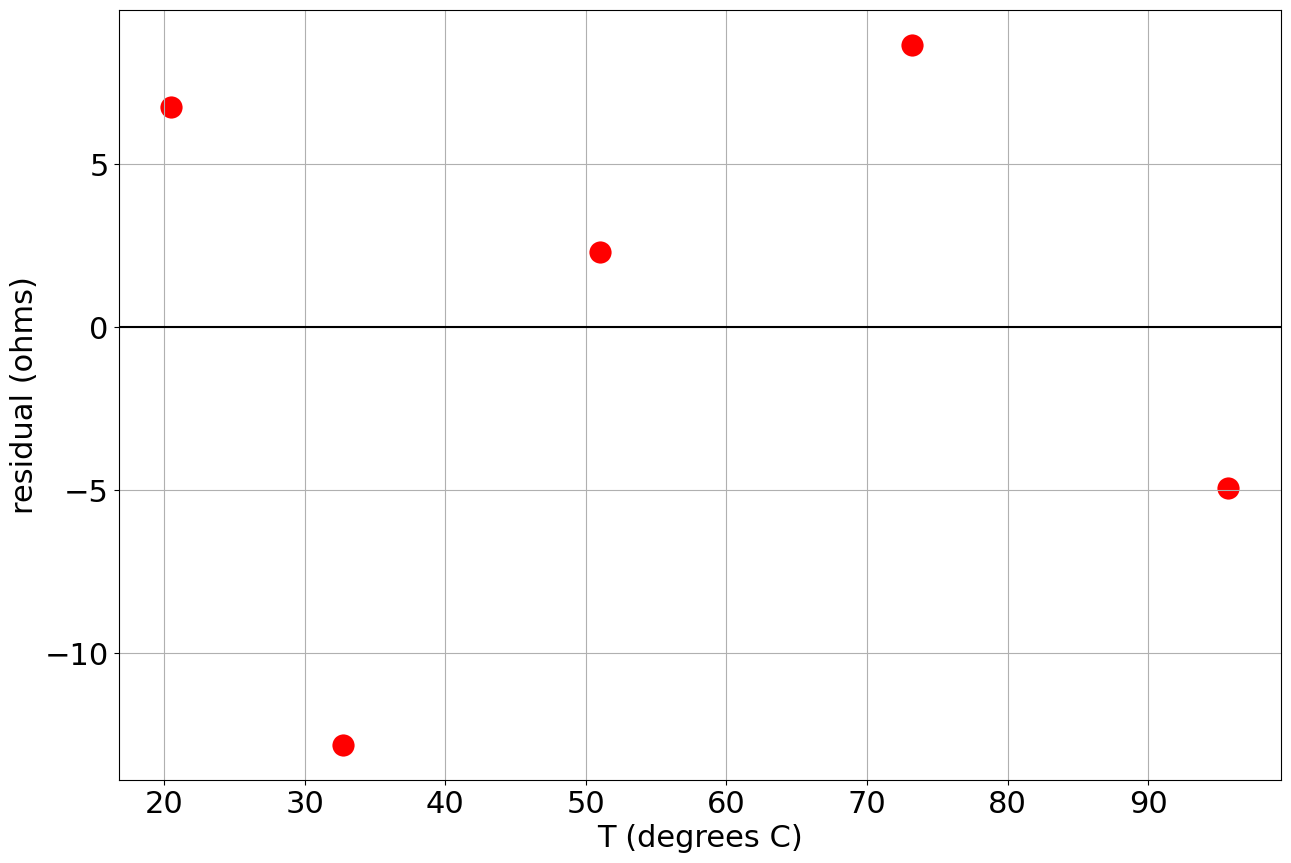

In [8]:
r = m*T + c - R
print("residuals:", r)
print("sum of residuals:", np.sum(r))

plt.grid(True)
plt.xlabel('T (degrees C)')
plt.ylabel('residual (ohms)')
plt.axhline(0, color='black')
plt.scatter(T, r, color='red', linewidths=10);

The sum is zero up to round-off, and the residuals show no obvious pattern, so a straight
line is a reasonable model for this data.

### Comparing with NumPy

NumPy's `polyfit` does least squares for a polynomial of any degree. With degree 1 it returns
the slope and intercept of the same line:

In [9]:
np.polyfit(T, R, 1)

array([  3.39487252, 702.17206279])

## Anscombe's quartet

In 1973 the statistician Francis Anscombe constructed four small data sets to make a point about
fitting. Here they are. Data sets I, II and III share the same $x$-values.

In [10]:
x123 = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5])
x4   = np.array([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8])

y1 = np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68])
y2 = np.array([9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74])
y3 = np.array([7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73])
y4 = np.array([6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])

quartet = [(x123, y1), (x123, y2), (x123, y3), (x4, y4)]
names = ['I', 'II', 'III', 'IV']

Before plotting anything, let's fit a line to each data set and compute some numbers that are
often used to summarise a fit: the means of $x$ and $y$, the correlation coefficient (computed
with `np.corrcoef`), and the root-mean-square residual

$$ \sigma = \sqrt{\frac{1}{n-2}\sum_i r_i^2} . $$

This measures the typical size of a residual, in the units of $y$.

In [11]:
for name, (x, y) in zip(names, quartet):
    m, c = LeastSquaresLine(x, y)
    r = m*x + c - y
    sigma = np.sqrt(np.sum(r**2)/(len(x) - 2))
    corr = np.corrcoef(x, y)[0, 1]
    print(f"{name:>3}:  mean x = {np.mean(x):.2f},  mean y = {np.mean(y):.2f},  "
          f"y = {c:.2f} + {m:.3f} x,  correlation = {corr:.3f},  sigma = {sigma:.2f}")

  I:  mean x = 9.00,  mean y = 7.50,  y = 3.00 + 0.500 x,  correlation = 0.816,  sigma = 1.24
 II:  mean x = 9.00,  mean y = 7.50,  y = 3.00 + 0.500 x,  correlation = 0.816,  sigma = 1.24
III:  mean x = 9.00,  mean y = 7.50,  y = 3.00 + 0.500 x,  correlation = 0.816,  sigma = 1.24
 IV:  mean x = 9.00,  mean y = 7.50,  y = 3.00 + 0.500 x,  correlation = 0.817,  sigma = 1.24


Every one of these numbers is the same for all four data sets, to two or three significant
figures. Judged by the numbers alone, the four fits are equally good. Now let's look at the
data.

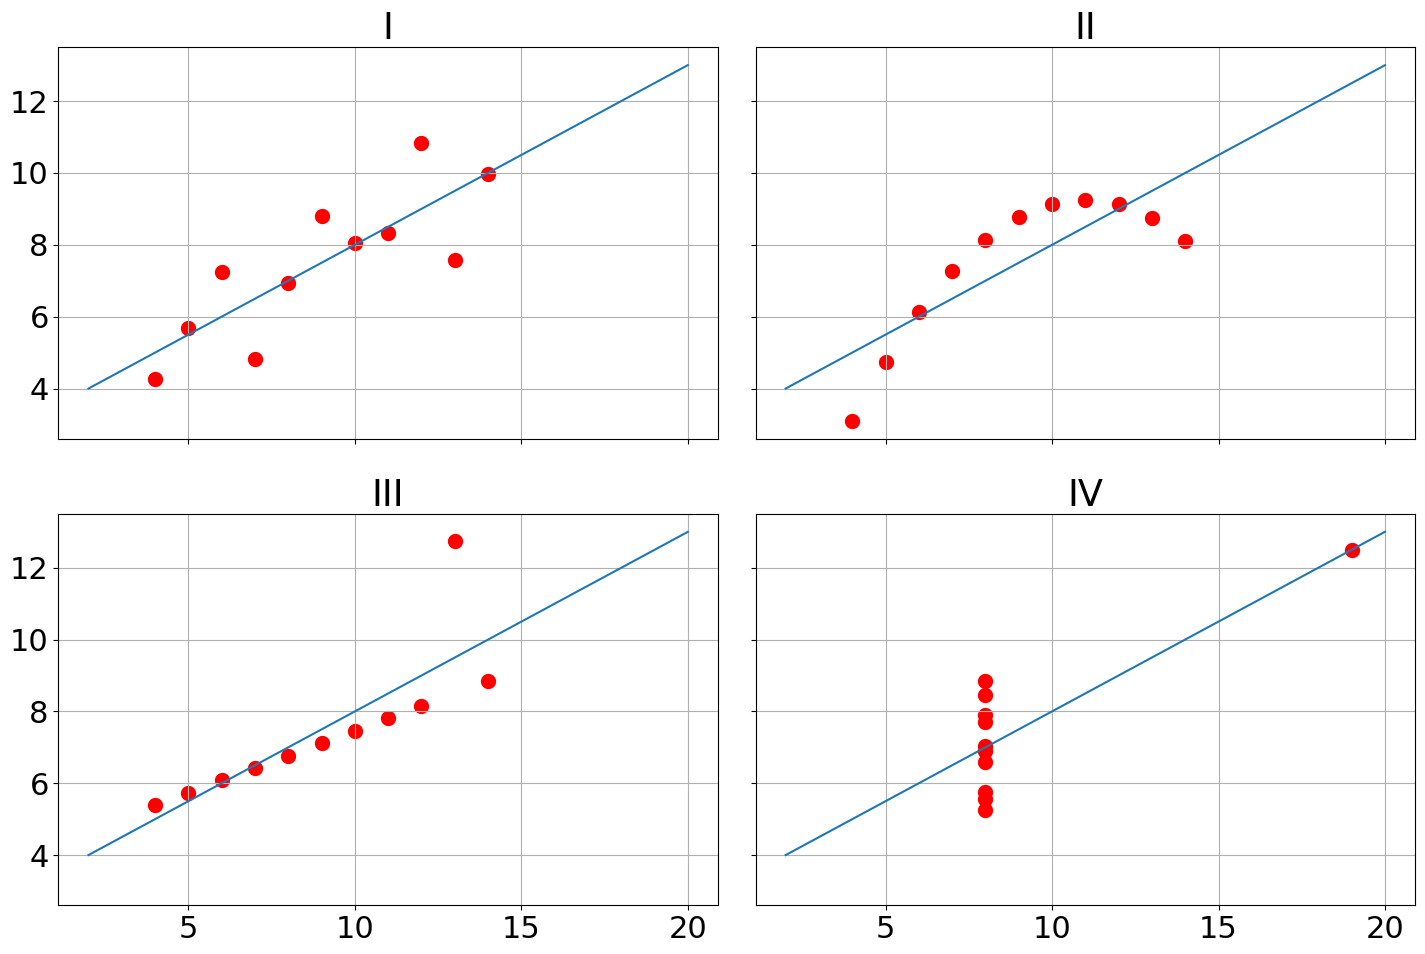

In [12]:
xplot = np.linspace(2, 20, 100)

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for ax, name, (x, y) in zip(axes.flat, names, quartet):
    m, c = LeastSquaresLine(x, y)
    ax.grid(True)
    ax.scatter(x, y, color='red', linewidths=5)
    ax.plot(xplot, m*xplot + c)
    ax.set_title(name)
plt.tight_layout()

They are nothing alike:

- **I** is what a straight-line fit expects: points scattered about a line.
- **II** is a smooth curve with no noise at all. A straight line is the wrong model.
- **III** lies exactly on a line except for one bad point, which drags the fit away from the
  other ten.
- **IV** has no information about the slope except a single point. Remove it and the slope cannot
  be found at all.

The residual plots make the same point. For a good model they look like random scatter about
zero; here only data set I does.

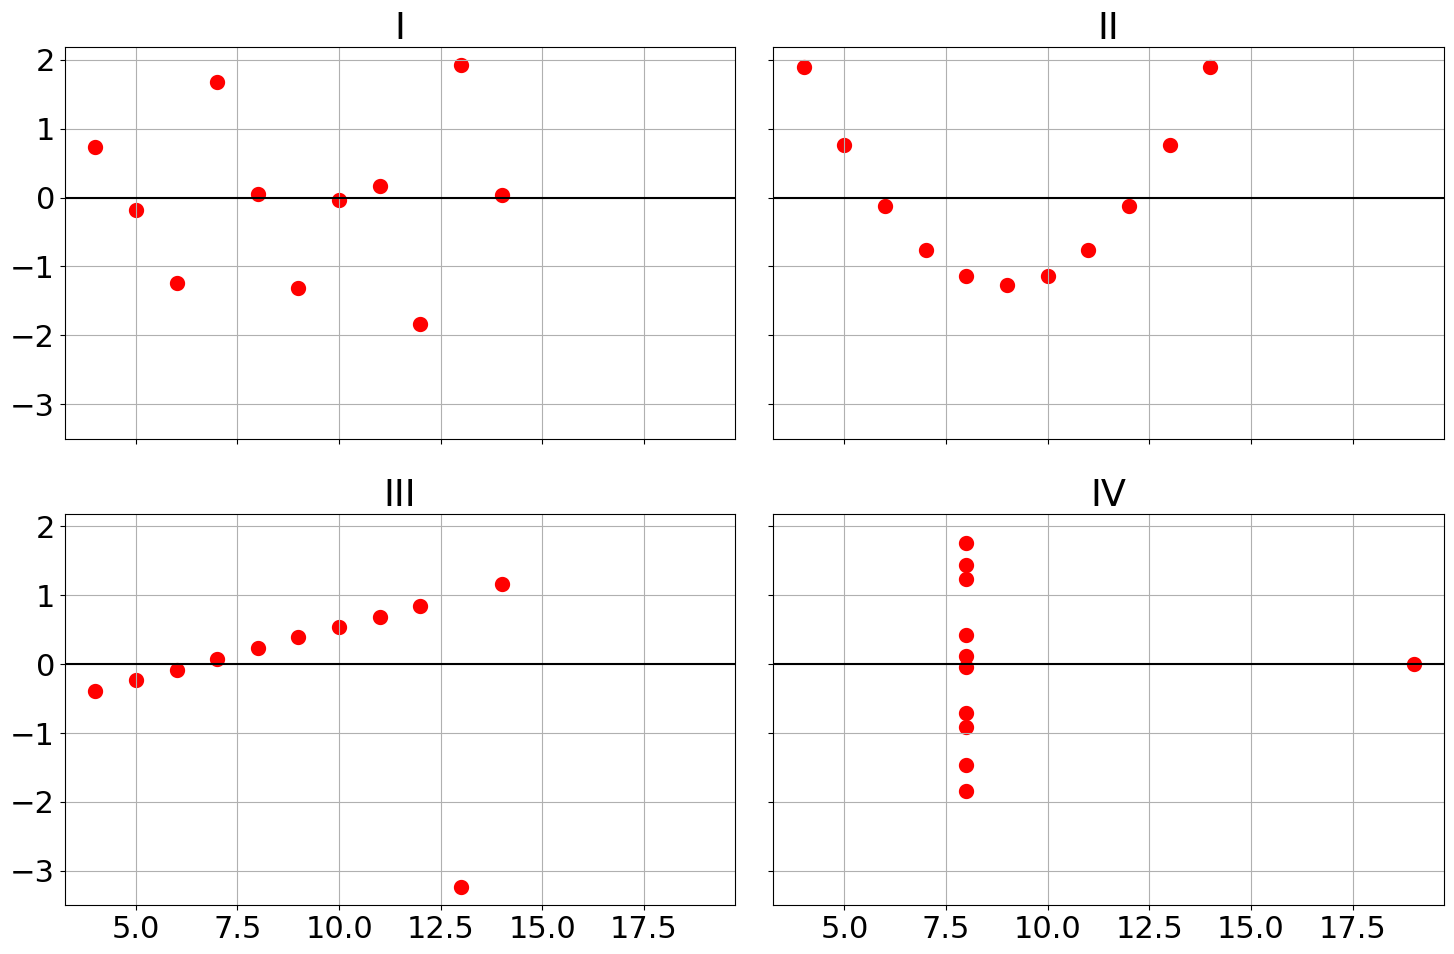

In [13]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for ax, name, (x, y) in zip(axes.flat, names, quartet):
    m, c = LeastSquaresLine(x, y)
    ax.grid(True)
    ax.axhline(0, color='black')
    ax.scatter(x, m*x + c - y, color='red', linewidths=5)
    ax.set_title(name)
plt.tight_layout()

The curve in II, the single large residual in III (and the way it tilts the line away from the
other ten points, whose residuals now climb steadily), and the lone point in IV all stand out
at a glance, but none of them shows up in the summary numbers.

**The lesson: always plot your data, and plot the residuals of your fit.** The least-squares
formulas will return a line for any data you give them. Whether that line means anything is
something only you can judge, and a plot is the quickest way to do it.